In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve,
                             auc, precision_recall_curve, average_precision_score, f1_score, accuracy_score)
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, precision_recall_curve
import joblib as jb
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier

In [3]:
xgb_model = jb.load("../models/XGBoost_final_model.joblib")
rf_model = jb.load("../models/RandomForest_final_model.joblib")

In [15]:
test = pd.read_csv("../data/test.csv")
X_test = test.drop(columns=["Class", "Time"])
y_test = test["Class"]

In [16]:
print("Random Forest Model Classification Report:")
print(classification_report(y_test, rf_model.predict(X_test), target_names=["Non-Fraud", "Fraud"]))

Random Forest Model Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56864
       Fraud       0.80      0.84      0.82        98

    accuracy                           1.00     56962
   macro avg       0.90      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [17]:
print("XGBoost Model Classification Report:")
print(classification_report(y_test, xgb_model.predict(X_test), target_names=["Non-Fraud", "Fraud"]))

XGBoost Model Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56864
       Fraud       0.79      0.87      0.83        98

    accuracy                           1.00     56962
   macro avg       0.89      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962



The recall and F1-score are higher for XGBoost, whereas the precision is higher for the Random Forest model, implying that the XGBoost classifier is better equipped to find fraudelent transactions, however the Random Forest model is more accurate in predicting positive instances. For a problem like fraudulent transaction detection, it is more important to avoid false negatives than avoiding false positives.

In [18]:
rf_matrix = confusion_matrix(y_test, rf_model.predict(X_test))
xgb_matrix = confusion_matrix(y_test, xgb_model.predict(X_test))

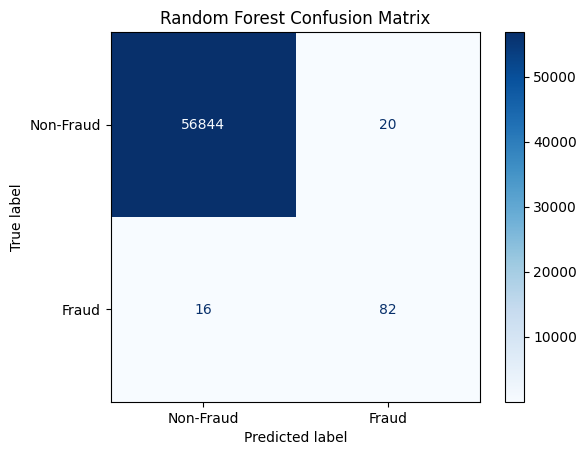

In [19]:
ConfusionMatrixDisplay(rf_matrix, display_labels=["Non-Fraud", "Fraud"]).plot(cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix")
plt.savefig("../reports/figures/rf_confusion_matrix.png")
plt.show()

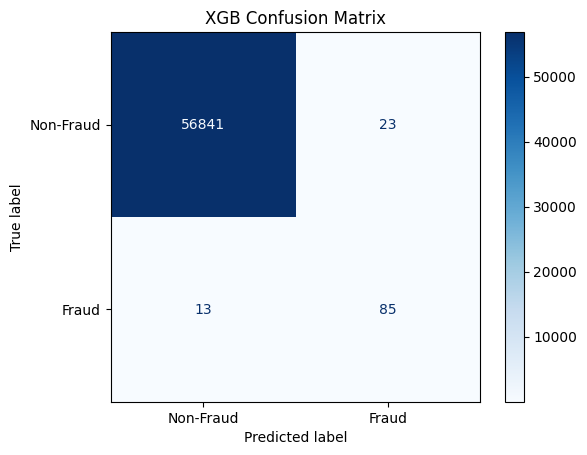

In [20]:
ConfusionMatrixDisplay(xgb_matrix, display_labels=["Non-Fraud", "Fraud"]).plot(cmap=plt.cm.Blues)
plt.title("XGB Confusion Matrix")
plt.savefig("../reports/figures/xgb_confusion_matrix.png")
plt.show()

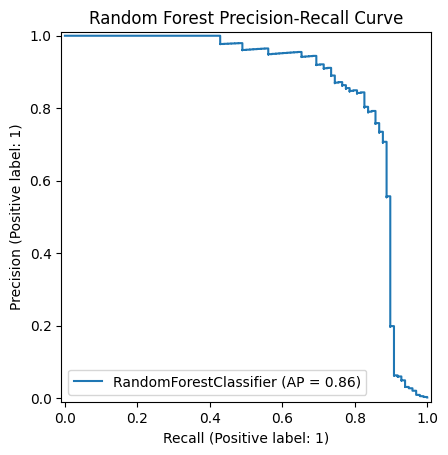

In [21]:
PrecisionRecallDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("Random Forest Precision-Recall Curve")
plt.savefig("../reports/figures/rf_precision_recall_curve.png")
plt.show()

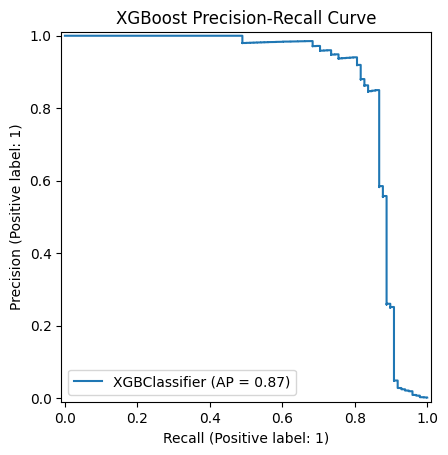

In [22]:
PrecisionRecallDisplay.from_estimator(xgb_model, X_test, y_test)
plt.title("XGBoost Precision-Recall Curve")
plt.savefig("../reports/figures/xgb_precision_recall_curve.png")
plt.show()

When comparing the precision-recall curves, it is important to consider what level of precision is acceptable for the situation. False positives are costly for credit card companies as they waste resources investigaing, and it lowers customer satisfaction. Therefore, we can select a precision value of $0.8$ to check if the recall is sufficient at that point.

In [23]:
rf_probs = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]  
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_probs)
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, xgb_probs)

In [26]:
target_precision = 0.8

rf_recall_at_target = rf_recall[rf_precision >= target_precision]
if len(rf_recall_at_target) > 0:
    recall_value = max(rf_recall_at_target)
else:
    recall_value = 0
print(f"RF Recall at precision ≥ {target_precision}: {recall_value:.2f}")

RF Recall at precision ≥ 0.8: 0.84


In [27]:
target_precision = 0.8

xgb_recall_at_target = xgb_recall[xgb_precision >= target_precision]
if len(xgb_recall_at_target) > 0:
    recall_value = max(xgb_recall_at_target)
else:
    recall_value = 0
print(f"XGB Recall at precision ≥ {target_precision}: {recall_value:.2f}")

XGB Recall at precision ≥ 0.8: 0.87


Here, we can see that the XGBoost model has a higher recall with precision $\ge 0.8$, so it is more suitable for detecting fraudulent credit card transactions.